# 幸福指数预测

SVM回归库包括SVR、NuSVR和LinearSVR三个类，其中，SVR和NuSVR的区别也仅在于对损失的度量方式不同；LinearSVR是线性回归，只能使用线性核函数。

已知影响人们幸福指数（Y: happyScore）的相关因素包括平均收入（F1: avg_income）、中等收入（F2: median_income）、收入不平衡度（F3: income_inequality），利用如表8-5所示数据构建幸福指数预测模型以对人们幸福指数进行预测，具体要求如下：

1. 对不同特征之间以及特征与输出之间的相关性进行分析。
2. 构建幸福指数预测模型并对比不同Ｃ值时的拟合优度。

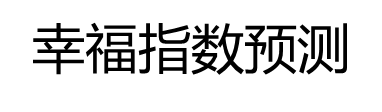
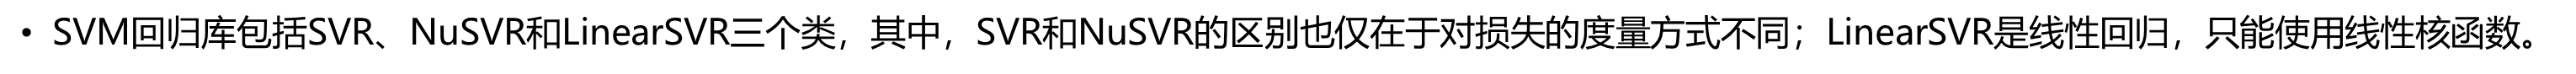

In [1]:
import pandas as pd  # 导入数据结构与分析库

# 导入绘图库
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split  # 导入数据划分模型
from sklearn.svm import SVR  # 导入SVM回归模块
from sklearn.metrics import r2_score  # 导入R2分数模块
from sklearn.preprocessing import StandardScaler  # 导入数据标准化模块

In [2]:
data = pd.read_csv('./happyscore_income.csv', encoding='gbk')
print('样本数与特征数', data.shape)

样本数与特征数 (40, 4)


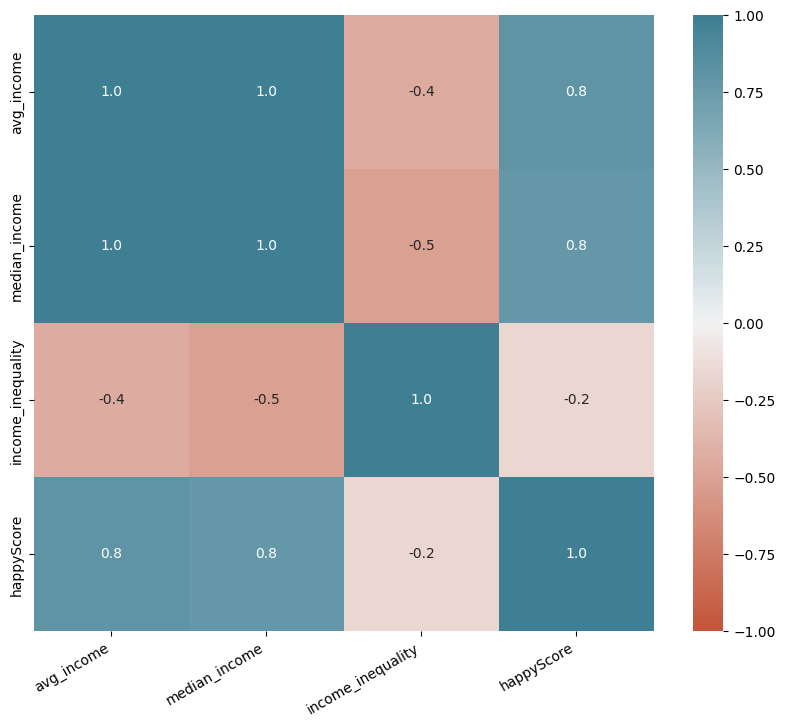

In [3]:
# 特征相关性分析
corr = data[data.columns[0:]].corr()
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    corr,
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=False, annot=True, fmt='.1f')
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=30,
    horizontalalignment='right'
)
plt.show()

<Axes: xlabel='income_inequality', ylabel='happyScore'>

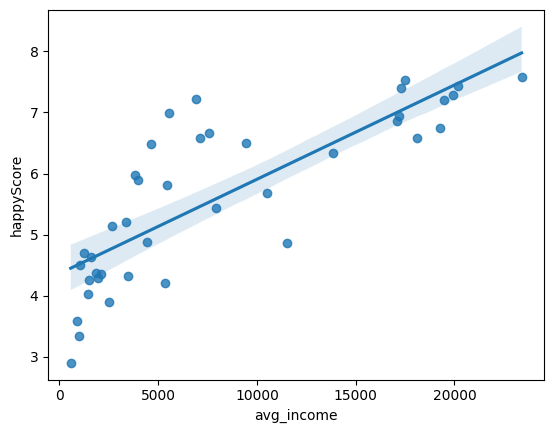

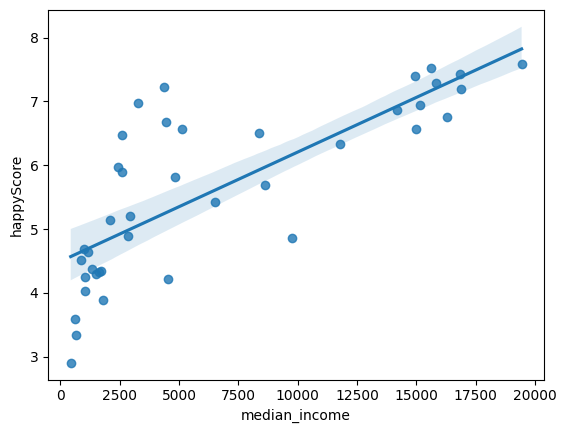

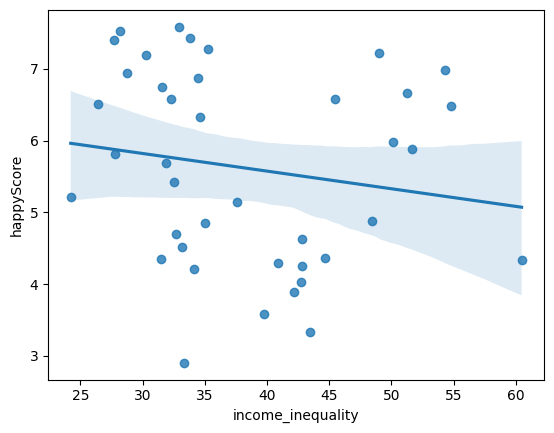

In [5]:
# 幸福指数与平均收入之间相关性
plt.figure(2)
sns.regplot(x=data['avg_income'], y=data['happyScore'])
# 幸福指数与中等收入之间相关性
plt.figure(3)
sns.regplot(x=data['median_income'], y=data['happyScore'])
# 幸福指数与收入不均衡指标之间相关性
plt.figure(4)
sns.regplot(x=data['income_inequality'], y=data['happyScore'])

In [7]:
# 构建幸福指数预测模型
x = data[['avg_income', 'median_income']]
y = data['happyScore']

In [9]:
# 数据标准化处理
scaler = StandardScaler()
x_ = scaler.fit_transform(x)
# 将数据划分为训练数据与测试数据
x_train, x_test, y_train, y_test = train_test_split(x_, y, test_size=0.5)

In [10]:
# 支持向量回归模型构建[C=1]
SV = SVR(kernel='rbf', C=2, gamma=1)
# 支持向量回归模型训练
SV = SV.fit(x_train, y_train)
# 支持向量回归模型评估
print('训练样本拟合优度(C=2):', r2_score(y_train, SV.predict(x_train)))
print('测试样本拟合优度(C=2):', r2_score(y_test, SV.predict(x_test)))

训练样本拟合优度(C=2): 0.8095243039753615
测试样本拟合优度(C=2): 0.6832308563597331


In [11]:
# 支持向量回归模型构建[参数设置2]
SV = SVR(kernel='rbf', C=0.1, gamma=1)
# 支持向量回归模型训练
SV = SV.fit(x_train, y_train)
# 支持向量回归模型评估
print('训练样本拟合优度(C=0.1):', r2_score(y_train, SV.predict(x_train)))
print('测试样本拟合优度(C=0.1):', r2_score(y_test, SV.predict(x_test)))

训练样本拟合优度(C=0.1): 0.43944153398194197
测试样本拟合优度(C=0.1): 0.3579815776235441
